# 🏥 Hospital Management Data Analytics

### End-to-End CSV Workflow

**Workflow:**  
**Read CSV → Inspect → Clean → Transform → Validate → Analyze → Export**

This notebook is built specifically for the **`hospital_management_dataset (1).csv`** file.

The dataset contains synthetic hospital-management records covering patient demographics, appointments, departments, waiting time, basic recorded measurements, diagnoses, doctors, patient type, appointment status, and treatment plans.

> **Note:** The dataset is synthetic and intended for educational/data-analytics purposes. The analysis is descriptive and is **not a clinical diagnosis or medical prediction system**.


# 1. Read CSV

Load the hospital-management CSV into a Pandas DataFrame and confirm that the file has been read successfully.


In [3]:
# ============================================================
# HOSPITAL MANAGEMENT DATA PIPELINE
# READ → INSPECT → CLEAN → TRANSFORM → VALIDATE → ANALYZE → EXPORT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# ============================================================
# 1. READ CSV
# ============================================================

print("=" * 70)
print("1. READ CSV")
print("=" * 70)

# Get current notebook working directory
current_folder = Path.cwd()

print("Current working folder:")
print(current_folder)

# Find all CSV files in the current folder
csv_files = list(current_folder.glob("*.csv"))

print("\nCSV files found:")

if len(csv_files) == 0:
    print("No CSV file found in the current folder.")
    print("\nPlease keep your CSV file in the same folder as the notebook.")
    raise FileNotFoundError(
        "CSV file not found. Put your hospital CSV beside the notebook."
    )

for i, file in enumerate(csv_files, 1):
    print(f"{i}. {file.name}")

# ------------------------------------------------------------
# Select CSV automatically
# ------------------------------------------------------------

file_path = csv_files[0]

print("\nSelected file:")
print(file_path)

# Read CSV
df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

1. READ CSV
Current working folder:
c:\Users\PAVITHRA\Desktop

CSV files found:
1. hospital_management_dataset (2).csv
2. MUC01_Retail_Sales_Cleaned.csv

Selected file:
c:\Users\PAVITHRA\Desktop\hospital_management_dataset (2).csv

Dataset loaded successfully!
Rows: 50
Columns: 20


,patient_id,name,age,age_group,gender,department,appointment_id,appointment_date,arrival_time,consultation_time,waiting_time_min,hemoglobin_result,heart_rate,steps,diagnosis,doctor_name,doctor_note,patient_type,appointment_status,treatment_plan
0,P001,Ananya Rao,45,Adult,Female,Cardiology,A001,2026-09-15,09:00,09:35,35,13.2,82,4200,Hypertension,Dr. Mehta,Routine follow-up,Outpatient,Completed,Prescription updated
1,P002,Arjun Kumar,32,Young Adult,Male,General Medicine,A002,2026-09-15,09:10,09:25,15,14.1,76,6500,Viral fever,Dr. Reddy,Stable condition,Outpatient,Completed,Continue medication
2,P003,Meera Nair,67,Elderly,Female,Cardiology,A003,2026-09-15,09:20,10:15,55,10.2,98,1800,Heart failure,Dr. Sharma,Needs additional observation,Inpatient,Observation,ECG recommended
3,P004,Vikram Singh,51,Senior,Male,Orthopedics,A004,2026-09-15,09:30,10:00,30,15.0,88,5200,Osteoarthritis,Dr. Kapoor,Knee pain,Outpatient,Completed,Physiotherapy advised
4,P005,Sneha Iyer,29,Young Adult,Female,Dermatology,A005,2026-09-15,09:40,10:05,25,12.8,72,8400,Dermatitis,Dr. Joseph,Skin irritation,Outpatient,Completed,Topical treatment prescribed


# 2. Inspect

Understand the structure of the dataset before making any changes.

We inspect:
- column names
- data types
- missing values
- duplicate records
- unique values in important categorical fields
- numerical summary statistics


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(2))
)
display(missing_summary)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe().T)

print("\nCategorical overview:")
for col in ["gender", "department", "patient_type", "appointment_status"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))


Column names:
['patient_id', 'name', 'age', 'age_group', 'gender', 'department', 'appointment_id', 'appointment_date', 'arrival_time', 'consultation_time', 'waiting_time_min', 'hemoglobin_result', 'heart_rate', 'steps', 'diagnosis', 'doctor_name', 'doctor_note', 'patient_type', 'appointment_status', 'treatment_plan']

Data types:


,dtype
patient_id,object
name,object
age,int64
age_group,object
gender,object
department,object
appointment_id,object
appointment_date,object
arrival_time,object
consultation_time,object



Missing values:


,missing_count,missing_percent
patient_id,0,0.0
name,0,0.0
age,0,0.0
age_group,0,0.0
gender,0,0.0
department,0,0.0
appointment_id,0,0.0
appointment_date,0,0.0
arrival_time,0,0.0
consultation_time,0,0.0



Duplicate rows: 0

Numerical summary:


...

,count
department,
General Medicine,10
Cardiology,8
Orthopedics,5
Dermatology,5
Neurology,5
Gynecology,4
ENT,4
Ophthalmology,4
Pulmonology,4



patient_type:


,count
patient_type,
Outpatient,39
Inpatient,11



appointment_status:


,count
appointment_status,
Completed,39
Observation,11


# 3. Clean

Clean the dataset without changing its intended meaning.

Cleaning steps:
1. Remove exact duplicate rows.
2. Strip unwanted spaces from text fields.
3. Standardize date and time fields.
4. Convert numerical fields to numeric types.
5. Handle missing numeric values with the column median if any occur.
6. Handle missing categorical values with `"Unknown"` if any occur.
7. Standardize the existing age-group values from the numeric age so that the category is consistent.


In [ ]:
# Work on a copy so the raw DataFrame remains available for comparison.
clean_df = df.copy()

# 1. Remove exact duplicates
before_duplicates = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
duplicates_removed = before_duplicates - len(clean_df)

# 2. Clean text columns
text_columns = [
    "patient_id", "name", "age_group", "gender", "department",
    "appointment_id", "diagnosis", "doctor_name", "doctor_note",
    "patient_type", "appointment_status", "treatment_plan"
]

for col in text_columns:
    clean_df[col] = clean_df[col].astype("string").str.strip()

# 3. Convert date/time columns
clean_df["appointment_date"] = pd.to_datetime(
    clean_df["appointment_date"], errors="coerce"
)

for col in ["arrival_time", "consultation_time"]:
    clean_df[col] = pd.to_datetime(
        clean_df[col], format="%H:%M", errors="coerce"
    ).dt.time

# 4. Convert numeric columns
numeric_columns = [
    "age", "waiting_time_min", "hemoglobin_result",
    "heart_rate", "steps"
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# 5. Fill missing numeric values with median
numeric_missing_before = clean_df[numeric_columns].isna().sum()
for col in numeric_columns:
    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# 6. Fill missing categorical values
for col in text_columns:
    clean_df[col] = clean_df[col].fillna("Unknown")

# 7. Rebuild age groups consistently from age
age_bins = [0, 18, 35, 50, 65, np.inf]
age_labels = ["Child", "Young Adult", "Adult", "Senior", "Elderly"]

clean_df["age_group"] = pd.cut(
    clean_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
).astype("string")

print("Duplicates removed:", duplicates_removed)
print("\nMissing numeric values found before filling:")
display(numeric_missing_before.to_frame("missing_count"))

print("\nCleaned dataset preview:")
display(clean_df.head())


Duplicates removed: 0

Missing numeric values found before filling:


,missing_count
age,0
waiting_time_min,0
hemoglobin_result,0
heart_rate,0
steps,0



Cleaned dataset preview:


,patient_id,name,age,age_group,gender,department,appointment_id,appointment_date,arrival_time,consultation_time,waiting_time_min,hemoglobin_result,heart_rate,steps,diagnosis,doctor_name,doctor_note,patient_type,appointment_status,treatment_plan
0,P001,Ananya Rao,45,Adult,Female,Cardiology,A001,2026-09-15,09:00:00,09:35:00,35,13.2,82,4200,Hypertension,Dr. Mehta,Routine follow-up,Outpatient,Completed,Prescription updated
1,P002,Arjun Kumar,32,Young Adult,Male,General Medicine,A002,2026-09-15,09:10:00,09:25:00,15,14.1,76,6500,Viral fever,Dr. Reddy,Stable condition,Outpatient,Completed,Continue medication
2,P003,Meera Nair,67,Elderly,Female,Cardiology,A003,2026-09-15,09:20:00,10:15:00,55,10.2,98,1800,Heart failure,Dr. Sharma,Needs additional observation,Inpatient,Observation,ECG recommended
3,P004,Vikram Singh,51,Senior,Male,Orthopedics,A004,2026-09-15,09:30:00,10:00:00,30,15.0,88,5200,Osteoarthritis,Dr. Kapoor,Knee pain,Outpatient,Completed,Physiotherapy advised
4,P005,Sneha Iyer,29,Young Adult,Female,Dermatology,A005,2026-09-15,09:40:00,10:05:00,25,12.8,72,8400,Dermatitis,Dr. Joseph,Skin irritation,Outpatient,Completed,Topical treatment prescribed


# 4. Transform

Create useful analytical features from the hospital-management fields.

New features:
- **day_of_week** — appointment weekday
- **appointment_month** — appointment month
- **calculated_waiting_time_min** — waiting time recalculated from arrival and consultation times
- **waiting_time_category** — short / moderate / long waiting-time band for operational analysis
- **steps_category** — descriptive activity band based on recorded steps
- **recorded_vital_group** — descriptive grouping of recorded heart-rate values, not a clinical assessment
- **data_quality_flag** — checks whether the source waiting time matches the recalculated waiting time


In [ ]:
# Combine date + time into datetime values
clean_df["arrival_datetime"] = pd.to_datetime(
    clean_df["appointment_date"].astype(str) + " " +
    clean_df["arrival_time"].astype(str),
    errors="coerce"
)

clean_df["consultation_datetime"] = pd.to_datetime(
    clean_df["appointment_date"].astype(str) + " " +
    clean_df["consultation_time"].astype(str),
    errors="coerce"
)

# Recalculate waiting time from timestamps
clean_df["calculated_waiting_time_min"] = (
    clean_df["consultation_datetime"] - clean_df["arrival_datetime"]
).dt.total_seconds() / 60

clean_df["calculated_waiting_time_min"] = (
    clean_df["calculated_waiting_time_min"].round(0).astype("Int64")
)

# Calendar features
clean_df["day_of_week"] = clean_df["appointment_date"].dt.day_name()
clean_df["appointment_month"] = clean_df["appointment_date"].dt.to_period("M").astype(str)

# Operational waiting-time bands
clean_df["waiting_time_category"] = pd.cut(
    clean_df["calculated_waiting_time_min"],
    bins=[-np.inf, 20, 40, np.inf],
    labels=["Short (≤20 min)", "Moderate (21–40 min)", "Long (>40 min)"]
)

# Descriptive steps bands
clean_df["steps_category"] = pd.cut(
    clean_df["steps"],
    bins=[-np.inf, 3000, 7000, np.inf],
    labels=["Lower recorded steps", "Moderate recorded steps", "Higher recorded steps"]
)

# Descriptive heart-rate grouping; not a clinical judgment.
clean_df["recorded_vital_group"] = pd.cut(
    clean_df["heart_rate"],
    bins=[-np.inf, 79, 99, np.inf],
    labels=["Lower recorded range", "Middle recorded range", "Higher recorded range"]
)

# Compare source waiting time with recalculated waiting time
clean_df["waiting_time_difference_min"] = (
    clean_df["waiting_time_min"] - clean_df["calculated_waiting_time_min"]
)

clean_df["data_quality_flag"] = np.where(
    clean_df["waiting_time_difference_min"].abs() <= 1,
    "OK",
    "Check"
)

display(clean_df[
    [
        "patient_id", "appointment_date", "day_of_week",
        "waiting_time_min", "calculated_waiting_time_min",
        "waiting_time_category", "data_quality_flag"
    ]
].head(10))


,patient_id,appointment_date,day_of_week,waiting_time_min,calculated_waiting_time_min,waiting_time_category,data_quality_flag
0,P001,2026-09-15,Tuesday,35,35,Moderate (21–40 min),OK
1,P002,2026-09-15,Tuesday,15,15,Short (≤20 min),OK
2,P003,2026-09-15,Tuesday,55,55,Long (>40 min),OK
3,P004,2026-09-15,Tuesday,30,30,Moderate (21–40 min),OK
4,P005,2026-09-15,Tuesday,25,25,Moderate (21–40 min),OK
5,P006,2026-09-15,Tuesday,40,40,Moderate (21–40 min),OK
6,P007,2026-09-15,Tuesday,40,40,Moderate (21–40 min),OK
7,P008,2026-09-15,Tuesday,45,45,Long (>40 min),OK
8,P009,2026-09-15,Tuesday,30,30,Moderate (21–40 min),OK
9,P010,2026-09-15,Tuesday,40,40,Moderate (21–40 min),OK


# 5. Validate

Validate the cleaned and transformed dataset before analysis/export.

Checks include:
- required columns exist
- patient IDs and appointment IDs are present and unique
- ages are within a reasonable data-entry range
- waiting times are non-negative
- heart rate, hemoglobin, and steps are non-negative
- appointment dates and times were parsed successfully
- categorical fields contain expected values
- recalculated waiting time agrees with the source field


In [ ]:
required_columns = [
    "patient_id", "name", "age", "gender", "department",
    "appointment_id", "appointment_date", "arrival_time",
    "consultation_time", "waiting_time_min", "hemoglobin_result",
    "heart_rate", "steps", "diagnosis", "doctor_name",
    "patient_type", "appointment_status", "treatment_plan"
]

assert all(col in clean_df.columns for col in required_columns), "Missing required columns."
assert clean_df["patient_id"].notna().all(), "Missing patient IDs found."
assert clean_df["patient_id"].is_unique, "Duplicate patient IDs found."
assert clean_df["appointment_id"].notna().all(), "Missing appointment IDs found."
assert clean_df["appointment_id"].is_unique, "Duplicate appointment IDs found."

assert clean_df["age"].between(0, 120).all(), "Age outside 0–120 found."
assert (clean_df["waiting_time_min"] >= 0).all(), "Negative source waiting time found."
assert (clean_df["calculated_waiting_time_min"] >= 0).all(), "Negative calculated waiting time found."
assert (clean_df["hemoglobin_result"] >= 0).all(), "Negative hemoglobin value found."
assert (clean_df["heart_rate"] >= 0).all(), "Negative heart-rate value found."
assert (clean_df["steps"] >= 0).all(), "Negative steps value found."

assert clean_df["appointment_date"].notna().all(), "Invalid appointment date found."
assert clean_df["arrival_datetime"].notna().all(), "Invalid arrival time found."
assert clean_df["consultation_datetime"].notna().all(), "Invalid consultation time found."

allowed_patient_types = {"Outpatient", "Inpatient", "Unknown"}
allowed_statuses = {"Completed", "Observation", "Unknown"}

assert set(clean_df["patient_type"].unique()).issubset(allowed_patient_types)
assert set(clean_df["appointment_status"].unique()).issubset(allowed_statuses)

print("Waiting-time consistency check:")
display(clean_df["data_quality_flag"].value_counts().to_frame("records"))

assert (clean_df["data_quality_flag"] == "OK").all(), (
    "Some source waiting-time values do not match the calculated values."
)

print("✅ All validation checks passed successfully.")


Waiting-time consistency check:


,records
data_quality_flag,
OK,50


✅ All validation checks passed successfully.


# 6. Analyze

Perform descriptive analysis of the hospital-management dataset.

The analysis covers:
1. Overall patient/appointment summary
2. Department workload
3. Waiting-time performance
4. Patient type and appointment status
5. Doctor workload
6. Diagnosis frequency
7. Gender and age-group distribution
8. Recorded measurements and activity summaries


In [ ]:
# 6.1 Overall summary
summary = pd.DataFrame({
    "Metric": [
        "Total patient records",
        "Total appointments",
        "Departments",
        "Doctors",
        "Average age",
        "Average waiting time (min)",
        "Maximum waiting time (min)",
        "Average recorded steps"
    ],
    "Value": [
        clean_df["patient_id"].nunique(),
        clean_df["appointment_id"].nunique(),
        clean_df["department"].nunique(),
        clean_df["doctor_name"].nunique(),
        round(clean_df["age"].mean(), 2),
        round(clean_df["calculated_waiting_time_min"].mean(), 2),
        int(clean_df["calculated_waiting_time_min"].max()),
        round(clean_df["steps"].mean(), 2)
    ]
})

display(summary)


,Metric,Value
0,Total patient records,50.00
1,Total appointments,50.00
2,Departments,10.00
3,Doctors,10.00
4,Average age,44.78
5,Average waiting time (min),38.40
6,Maximum waiting time (min),55.00
7,Average recorded steps,5786.00


In [ ]:
# 6.2 Department analysis
department_analysis = (
    clean_df.groupby("department")
    .agg(
        appointments=("appointment_id", "count"),
        average_waiting_time_min=("calculated_waiting_time_min", "mean"),
        average_age=("age", "mean"),
        average_steps=("steps", "mean")
    )
    .round(2)
    .sort_values("appointments", ascending=False)
)

display(department_analysis)


,appointments,average_waiting_time_min,average_age,average_steps
department,,,,
General Medicine,10,34.0,41.10,6740.0
Cardiology,8,45.0,54.25,3437.5
Dermatology,5,31.0,31.60,8220.0
Neurology,5,46.0,52.20,4020.0
Orthopedics,5,41.0,52.20,4840.0
ENT,4,26.25,29.75,8875.0
Gynecology,4,38.75,31.75,7475.0
Ophthalmology,4,38.75,45.00,6400.0
Pulmonology,4,46.25,63.00,2225.0


In [ ]:
# 6.3 Patient type and appointment status
patient_type_summary = (
    clean_df["patient_type"]
    .value_counts()
    .rename_axis("patient_type")
    .reset_index(name="appointments")
)

status_summary = (
    clean_df["appointment_status"]
    .value_counts()
    .rename_axis("appointment_status")
    .reset_index(name="appointments")
)

print("Patient type:")
display(patient_type_summary)

print("Appointment status:")
display(status_summary)


Patient type:


,patient_type,appointments
0,Outpatient,39
1,Inpatient,11


Appointment status:


,appointment_status,appointments
0,Completed,39
1,Observation,11


In [ ]:
# 6.4 Doctor workload
doctor_analysis = (
    clean_df.groupby("doctor_name")
    .agg(
        appointments=("appointment_id", "count"),
        average_waiting_time_min=("calculated_waiting_time_min", "mean")
    )
    .round(2)
    .sort_values("appointments", ascending=False)
)

display(doctor_analysis)


,appointments,average_waiting_time_min
doctor_name,,
Dr. Reddy,10,34.0
Dr. Menon,9,42.78
Dr. Mehta,7,43.57
Dr. Joseph,5,31.0
Dr. Kapoor,5,41.0
Dr. Iyer,4,46.25
Dr. Rao,4,38.75
Dr. Shah,4,26.25
Dr. Sharma,1,55.0


In [ ]:
# 6.5 Diagnosis frequency
diagnosis_analysis = (
    clean_df["diagnosis"]
    .value_counts()
    .rename_axis("diagnosis")
    .reset_index(name="records")
)

display(diagnosis_analysis.head(15))

# 6.6 Demographic distribution
print("Gender distribution:")
display(
    clean_df["gender"]
    .value_counts()
    .rename_axis("gender")
    .reset_index(name="records")
)

print("Age-group distribution:")
display(
    clean_df["age_group"]
    .value_counts()
    .reindex(["Child", "Young Adult", "Adult", "Senior", "Elderly"], fill_value=0)
    .rename_axis("age_group")
    .reset_index(name="records")
)


,diagnosis,records
0,Hypertension,3
1,Heart failure,2
2,Osteoarthritis,2
3,Nutritional deficiency,2
4,Asthma,2
5,COPD,2
6,Arrhythmia,2
7,Tendonitis,2
8,Viral fever,1
9,Migraine,1


Gender distribution:


,gender,records
0,Female,25
1,Male,25


Age-group distribution:


,age_group,records
0,Child,0
1,Young Adult,16
2,Adult,17
3,Senior,12
4,Elderly,5


## 6.7 Visual Analysis

Create simple charts for the most useful operational questions:
- Which departments have more appointments?
- Which departments have longer average waiting times?
- How are appointments distributed by patient type?
- How are recorded steps distributed?


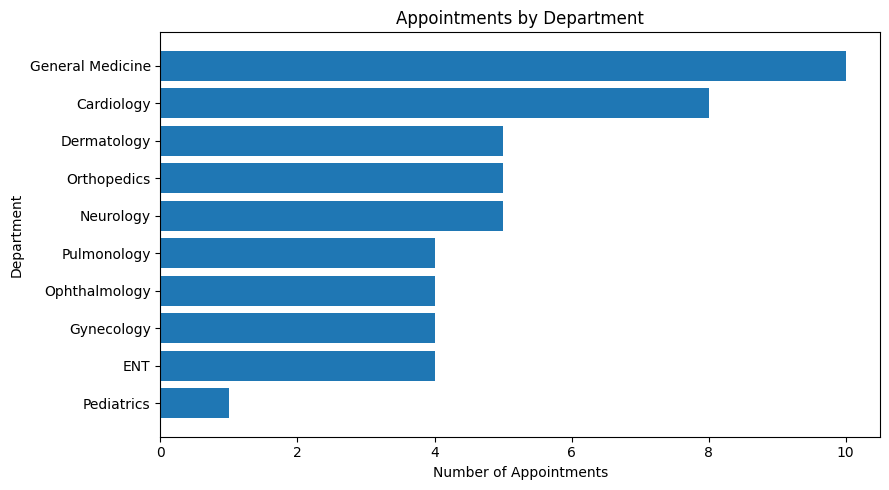

In [ ]:
# Chart 1 — Appointments by department
department_counts = clean_df["department"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(department_counts.index, department_counts.values)
plt.title("Appointments by Department")
plt.xlabel("Number of Appointments")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


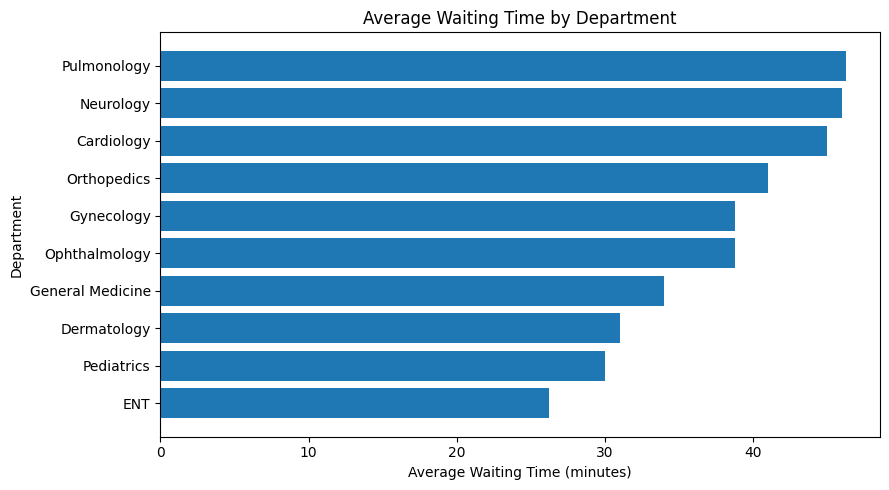

In [ ]:
# Chart 2 — Average waiting time by department
department_wait = (
    clean_df.groupby("department")["calculated_waiting_time_min"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(department_wait.index, department_wait.values)
plt.title("Average Waiting Time by Department")
plt.xlabel("Average Waiting Time (minutes)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


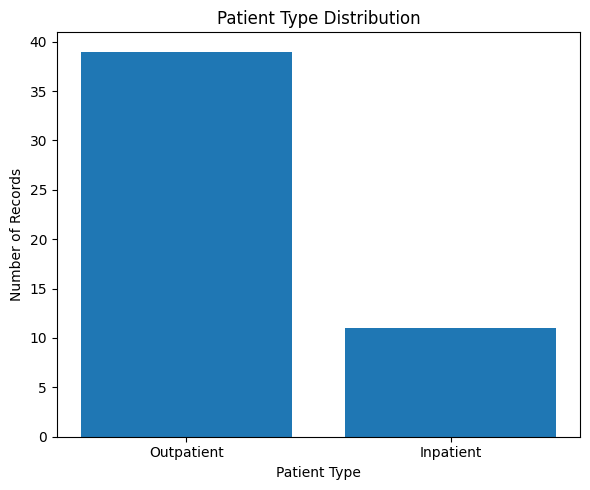

In [ ]:
# Chart 3 — Patient type distribution
patient_type_counts = clean_df["patient_type"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(patient_type_counts.index, patient_type_counts.values)
plt.title("Patient Type Distribution")
plt.xlabel("Patient Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


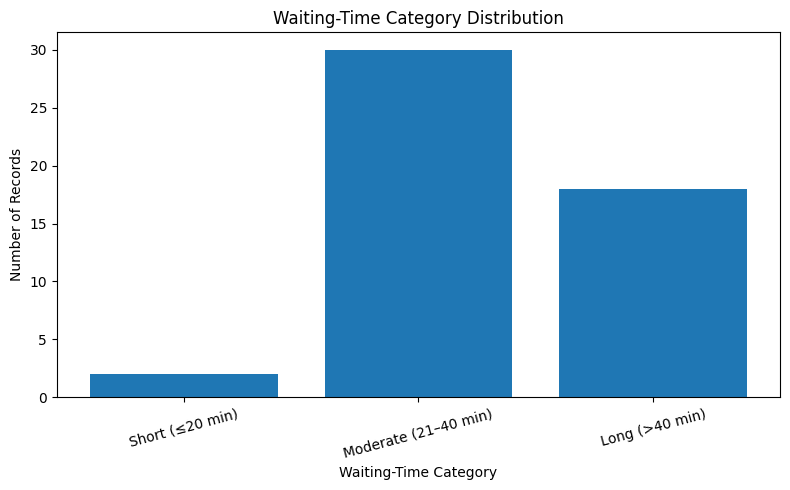

In [ ]:
# Chart 4 — Waiting-time category distribution
waiting_counts = (
    clean_df["waiting_time_category"]
    .value_counts()
    .reindex(["Short (≤20 min)", "Moderate (21–40 min)", "Long (>40 min)"], fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.bar(waiting_counts.index, waiting_counts.values)
plt.title("Waiting-Time Category Distribution")
plt.xlabel("Waiting-Time Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# 7. Export

Export the cleaned and transformed dataset and the main analytical summaries.

The exported files are designed for further use in **Excel, Power BI, Tableau, SQL, or Python**.


In [ ]:
# Keep the useful original fields plus analytical features.
final_columns = [
    "patient_id", "name", "age", "age_group", "gender", "department",
    "appointment_id", "appointment_date", "arrival_time", "consultation_time",
    "waiting_time_min", "calculated_waiting_time_min",
    "waiting_time_category", "hemoglobin_result", "heart_rate", "steps",
    "steps_category", "diagnosis", "doctor_name", "doctor_note",
    "patient_type", "appointment_status", "treatment_plan",
    "day_of_week", "appointment_month", "data_quality_flag"
]

analytics_df = clean_df[final_columns].copy()

processed_file = "hospital_management_analytics_cleaned.csv"
department_file = "hospital_department_summary.csv"
doctor_file = "hospital_doctor_summary.csv"

analytics_df.to_csv(processed_file, index=False)
department_analysis.reset_index().to_csv(department_file, index=False)
doctor_analysis.reset_index().to_csv(doctor_file, index=False)

print("Export completed:")
print("-", processed_file)
print("-", department_file)
print("-", doctor_file)

display(analytics_df.head())


Export completed:
- hospital_management_analytics_cleaned.csv
- hospital_department_summary.csv
- hospital_doctor_summary.csv


,patient_id,name,age,age_group,gender,department,appointment_id,appointment_date,arrival_time,consultation_time,waiting_time_min,calculated_waiting_time_min,waiting_time_category,hemoglobin_result,heart_rate,steps,steps_category,diagnosis,doctor_name,doctor_note,patient_type,appointment_status,treatment_plan,day_of_week,appointment_month,data_quality_flag
0,P001,Ananya Rao,45,Adult,Female,Cardiology,A001,2026-09-15,09:00:00,09:35:00,35,35,Moderate (21–40 min),13.2,82,4200,Moderate recorded steps,Hypertension,Dr. Mehta,Routine follow-up,Outpatient,Completed,Prescription updated,Tuesday,2026-09,OK
1,P002,Arjun Kumar,32,Young Adult,Male,General Medicine,A002,2026-09-15,09:10:00,09:25:00,15,15,Short (≤20 min),14.1,76,6500,Moderate recorded steps,Viral fever,Dr. Reddy,Stable condition,Outpatient,Completed,Continue medication,Tuesday,2026-09,OK
2,P003,Meera Nair,67,Elderly,Female,Cardiology,A003,2026-09-15,09:20:00,10:15:00,55,55,Long (>40 min),10.2,98,1800,Lower recorded steps,Heart failure,Dr. Sharma,Needs additional observation,Inpatient,Observation,ECG recommended,Tuesday,2026-09,OK
3,P004,Vikram Singh,51,Senior,Male,Orthopedics,A004,2026-09-15,09:30:00,10:00:00,30,30,Moderate (21–40 min),15.0,88,5200,Moderate recorded steps,Osteoarthritis,Dr. Kapoor,Knee pain,Outpatient,Completed,Physiotherapy advised,Tuesday,2026-09,OK
4,P005,Sneha Iyer,29,Young Adult,Female,Dermatology,A005,2026-09-15,09:40:00,10:05:00,25,25,Moderate (21–40 min),12.8,72,8400,Higher recorded steps,Dermatitis,Dr. Joseph,Skin irritation,Outpatient,Completed,Topical treatment prescribed,Tuesday,2026-09,OK


# 8. Final Conclusion

This notebook follows the complete hospital-management analytics workflow:

**Read CSV → Inspect → Clean → Transform → Validate → Analyze → Export**

### Key outputs
- A cleaned and transformed hospital-management dataset
- Department-level operational summary
- Doctor-level workload summary
- Descriptive analysis of waiting time, patient type, appointment status, demographics, diagnoses, and recorded measurements
- Visualizations for department workload and waiting-time patterns

The analysis is intended for **data-management and educational analytics**. Any medical interpretation or clinical decision should be made only by qualified healthcare professionals using appropriate clinical information and validated methods.
